In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import box
import numpy as np
from pyproj import CRS

In [3]:
# Load the shapefile
shapefile_path = r"D:\UNI_Stir\Projects\CI2D3\InProgress\reproj\ci2d3\CCIN12678_20181113_CI2D3_01.shp"  # Replace with your shapefile path
gdf = gpd.read_file(shapefile_path)

In [4]:
convex_hull_gdf = gpd.GeoDataFrame({'geometry': gdf.unary_union.convex_hull, 'convex_hull':[1]})

In [34]:
gdf.geometry.area

0        3.001887e+07
1        5.076813e+06
2        2.334108e+05
3        3.001887e+07
4        5.306329e+06
             ...     
25359    4.923598e+06
25360    7.320164e+06
25361    1.825226e+06
25362    1.528287e+06
25363    2.499988e+06
Length: 25364, dtype: float64

In [35]:
gdf.area

0        3.001887e+07
1        5.076813e+06
2        2.334108e+05
3        3.001887e+07
4        5.306329e+06
             ...     
25359    4.923598e+06
25360    7.320164e+06
25361    1.825226e+06
25362    1.528287e+06
25363    2.499988e+06
Length: 25364, dtype: float64

In [5]:
# Determine the bounding box of the shapefile
minx, miny, maxx, maxy = gdf.total_bounds

# Generate a grid of points within the bounding box
num_points = 10  # Adjust the number of points for higher or lower resolution
x_points = np.linspace(minx, maxx, num_points)
y_points = np.linspace(miny, maxy, num_points)
grid_points = np.array(np.meshgrid(x_points, y_points)).T.reshape(-1, 2)

# Create a GeoDataFrame from the points
points_gdf = gpd.GeoDataFrame(geometry=gpd.points_from_xy(grid_points[:, 0], grid_points[:, 1]), crs=gdf.crs)

# Buffer sizes (in square meters)
buffer_sizes = [gdf.area.quantile(0.20), gdf.area.quantile(0.50), gdf.area.quantile(0.90)]

# Target projection (EPSG:5937)
target_crs = "EPSG:5937"

# Function to calculate distortion
def calculate_distortion(original_area, projected_area, original_length, projected_length):
    area_distortion = (projected_area - original_area) / original_area
    length_distortion = (projected_length - original_length) / original_length
    return area_distortion, length_distortion


In [12]:
buffer_sizes

[338576.4710045937, 916487.0559142389, 11276160.309156148]

In [6]:
# List to store results
results = []

# Calculate distortions for each point and buffer size
for size in buffer_sizes:
    for point in points_gdf.geometry:
        buffer = point.buffer(np.sqrt(size / np.pi))  # Create buffer
        buffer_gdf = gpd.GeoDataFrame(geometry=[buffer], crs=gdf.crs)
        
        # Original area and length
        original_area = buffer_gdf.geometry.area.values[0]
        original_length = buffer_gdf.geometry.length.values[0]
        
        # Reproject to target CRS
        buffer_proj = buffer_gdf.to_crs(target_crs)
        
        # Projected area and length
        projected_area = buffer_proj.geometry.area.values[0]
        projected_length = buffer_proj.geometry.length.values[0]
        
        # Calculate distortions
        area_distortion, length_distortion = calculate_distortion(original_area, projected_area, original_length, projected_length)
        
        # Store the results
        results.append({
            'point': point,
            'buffer_size': size,
            'area_distortion': area_distortion,
            'length_distortion': length_distortion
        })

# Convert results to a GeoDataFrame for visualization
results_gdf = gpd.GeoDataFrame(results, geometry='point', crs=gdf.crs)

In [7]:
results_gdf

,point,buffer_size,area_distortion,length_distortion
0,POINT (152714.470 2122807.039),3.385765e+05,0.209168,0.099622
1,POINT (152714.470 2445041.799),3.385765e+05,0.184153,0.088188
2,POINT (152714.470 2767276.559),3.385765e+05,0.157121,0.075696
3,POINT (152714.470 3089511.319),3.385765e+05,0.127658,0.061912
4,POINT (152714.470 3411746.079),3.385765e+05,0.095202,0.046519
...,...,...,...,...
295,POINT (3595870.627 3733980.839),1.127616e+07,0.246804,0.116604
296,POINT (3595870.627 4056215.599),1.127616e+07,0.237069,0.112236
297,POINT (3595870.627 4378450.359),1.127616e+07,0.228609,0.108426
298,POINT (3595870.627 4700685.119),1.127616e+07,0.221676,0.105295


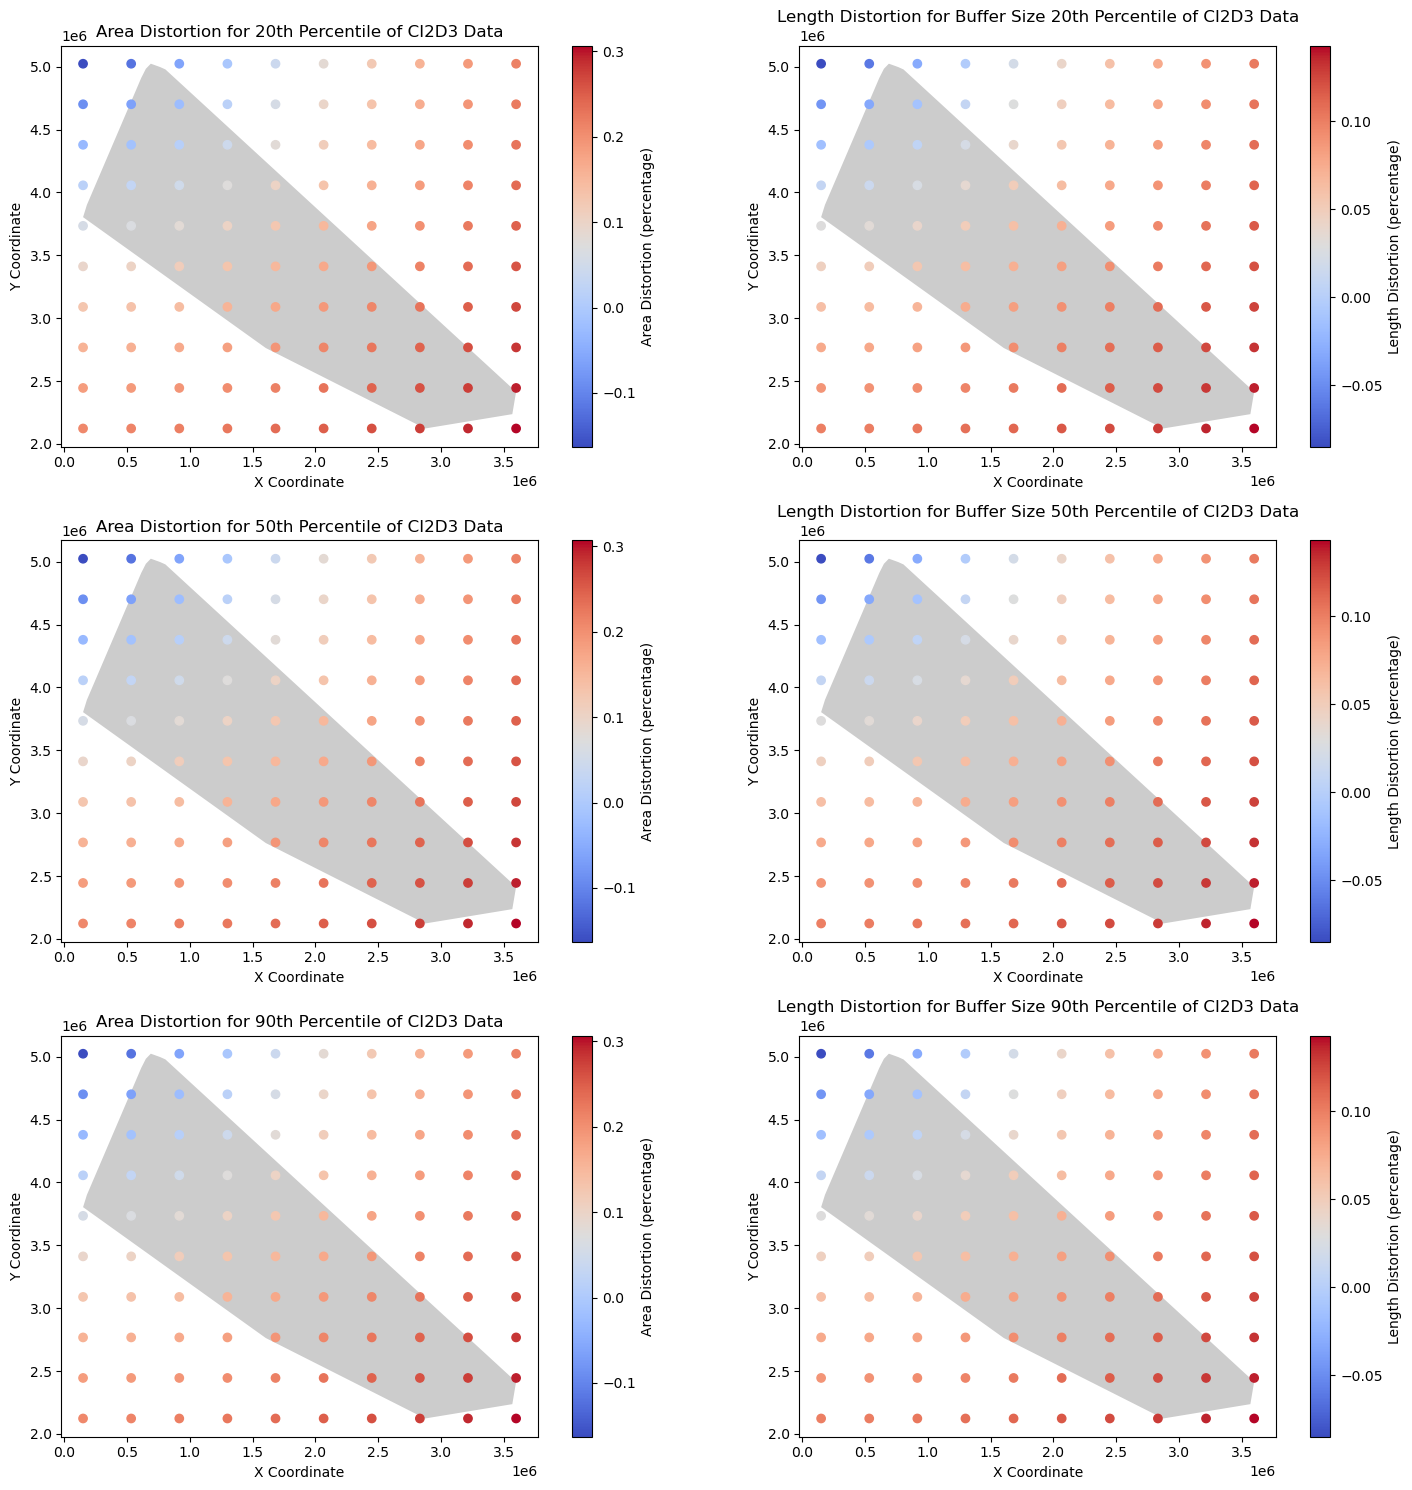

In [11]:

area_percentile = [20, 50, 90]

# Plotting the errors
fig, axs = plt.subplots(len(buffer_sizes), 2, figsize=(15, 15))

for idx, size in enumerate(buffer_sizes):
    # Filter results by buffer size
    size_gdf = results_gdf[results_gdf['buffer_size'] == size]

    # # Plot area distortion
    # #convex_hull_gdf.plot(ax=axs[idx, 0], color='black', alpha=0.2)
    # area_plot = size_gdf.plot(column='area_distortion', cmap='coolwarm', legend=True, ax=axs[idx, 0])
    # cbar = area_plot.get_figure().colorbar(area_plot.collections[0], ax=axs[idx, 0])
    # cbar.set_label('Area Distortion (percentage)')  # Set the label for the color bar
    # axs[idx, 0].set_title(f'Area Distortion for Buffer Size {size} sqm')

    convex_hull_gdf.plot(ax=axs[idx, 0], color='black', alpha=0.2)
    area_plot = size_gdf.plot(column='area_distortion', cmap='coolwarm', legend=False, ax=axs[idx, 0])
    cbar = area_plot.get_figure().colorbar(area_plot.collections[1], ax=axs[idx, 0])
    cbar.set_label('Area Distortion (percentage)')  # Set the label for the color bar
    axs[idx, 0].set_title(f'Area Distortion for {area_percentile[idx]}th Percentile of CI2D3 Data')

    # Plot length distortion
    convex_hull_gdf.plot(ax=axs[idx, 1], color='black', alpha=0.2)
    length_plot = size_gdf.plot(column='length_distortion', cmap='coolwarm', legend=False, ax=axs[idx, 1])
    cbar = length_plot.get_figure().colorbar(length_plot.collections[1], ax=axs[idx, 1])
    cbar.set_label('Length Distortion (percentage)')  # Set the label for the color bar
    axs[idx, 1].set_title(f'Length Distortion for Buffer Size {area_percentile[idx]}th Percentile of CI2D3 Data')


    # Set X and Y labels for both plots
    axs[idx, 0].set_xlabel('X Coordinate')
    axs[idx, 0].set_ylabel('Y Coordinate')
    axs[idx, 1].set_xlabel('X Coordinate')
    axs[idx, 1].set_ylabel('Y Coordinate')

plt.tight_layout()
plt.show()